# 05 — Solar Production Forecast

## What are we forecasting?

`sl_productie_kwh` — solar energy delivered to the household AC bus per 15-min slot.
This is the value the LP optimizer uses as its `solar` input.

This is **not** total panel output — it is the surplus that reached the bus
(grid export + battery charge). Direct self-consumption is invisible in the data.
We use this derived value because it is exactly what the LP needs.

## Why solar is easier to forecast than consumption

Solar follows physics: the sun position is predictable, clouds reduce it.
The key input is `poa_irradiance` (W/m²) — measured irradiance on the panel surface,
already accounting for panel tilt and orientation.

No lag features needed — solar today does not depend on solar yesterday.

## §1. Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE  = Path("../../Data/real_load/Final/optimization_input.csv")
SOLAR_FILE = Path("../../Data/real_load/Source Data/vilvoorde_zonneschijn.csv")
OUTPUT_FILE = Path("../../Data/real_load/Final/solar_forecast.csv")

print("OK")

OK


## §2. Load data

Two files:
- `optimization_input.csv` — 15-min household data. We need `sl_productie_kwh` (target).
- `vilvoorde_zonneschijn.csv` — hourly irradiance. We need it as features.

Let's load both and see what they contain.

In [22]:
# 15-min household data
df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
print("Household data columns:", df.columns.tolist())
print(f"Rows: {len(df)}, period: {df.index.min().date()} to {df.index.max().date()}")
print()

# Hourly irradiance
irr = pd.read_csv(SOLAR_FILE, index_col="time", parse_dates=True)
print("Irradiance columns:", irr.columns.tolist())
print(f"Rows: {len(irr)}, period: {irr.index.min().date()} to {irr.index.max().date()}")

Household data columns: ['price_eur_kwh', 'tarief', 'verbruik_kwh', 'ev_energie_kwh', 'afname_kwh', 'injectie_kwh', 'bat_laden_kwh_kw', 'bat_ontladen_kwh_kw', 'sl_productie_kwh']
Rows: 50112, period: 2024-11-01 to 2026-04-06

Irradiance columns: ['shortwave_radiation', 'direct_normal_irradiance', 'diffuse_radiation', 'sunshine_duration', 'sunshine_min_per_hour', 'poa_irradiance']
Rows: 12768, period: 2024-11-01 to 2026-04-16


## §3. Merge: hourly irradiance → 15-min

Irradiance is measured once per hour. Our target is per 15 minutes.
We resample by repeating each hourly value 4 times (`ffill` = forward fill).

Example: radiation at 10:00 → applied to 10:00, 10:15, 10:30, 10:45.

In [23]:
# Resample hourly -> 15-min by repeating each value
irr_15 = irr.resample("15min").ffill()

# Keep only the solar target column and join with irradiance
merged = df[["sl_productie_kwh"]].join(irr_15, how="left")
merged = merged.dropna()

print(f"Merged rows: {len(merged)}")
print(f"Missing values: {merged.isna().sum().sum()}")
print()
merged.head(6)

Merged rows: 50112
Missing values: 0



,sl_productie_kwh,shortwave_radiation,direct_normal_irradiance,diffuse_radiation,sunshine_duration,sunshine_min_per_hour,poa_irradiance
kwartier,,,,,,,
2024-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-11-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-11-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-11-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-11-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-11-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## §4. Explore: how well does irradiance predict solar output?

Before any model, let's see the raw relationship.

We only look at **daytime slots** (`poa_irradiance > 10 W/m²`).
Nighttime is trivially zero — easy to predict, not interesting.

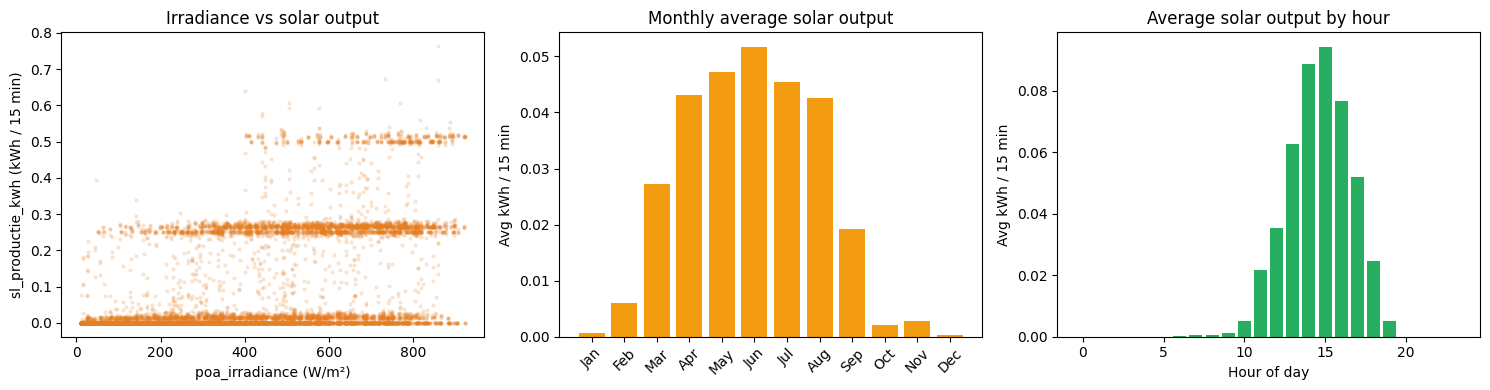

Daytime slots: 16468 of 50112 total (32.9%)
Correlation poa_irradiance <-> solar output: 0.561


In [24]:
# Daytime slots only
day = merged[merged["poa_irradiance"] > 10]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter: poa_irradiance vs solar output
axes[0].scatter(day["poa_irradiance"], day["sl_productie_kwh"],
                alpha=0.15, s=4, color="#e67e22")
axes[0].set_xlabel("poa_irradiance (W/m²)")
axes[0].set_ylabel("sl_productie_kwh (kWh / 15 min)")
axes[0].set_title("Irradiance vs solar output")

# Monthly average
merged["month"] = merged.index.month
labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = merged.groupby("month")["sl_productie_kwh"].mean()
axes[1].bar(monthly.index, monthly.values, color="#f39c12")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([labels[m-1] for m in range(1, 13)], rotation=45)
axes[1].set_title("Monthly average solar output")
axes[1].set_ylabel("Avg kWh / 15 min")

# Average by hour
merged["hour"] = merged.index.hour
hourly = merged.groupby("hour")["sl_productie_kwh"].mean()
axes[2].bar(hourly.index, hourly.values, color="#27ae60")
axes[2].set_xlabel("Hour of day")
axes[2].set_ylabel("Avg kWh / 15 min")
axes[2].set_title("Average solar output by hour")

plt.tight_layout()
plt.show()

corr = day["poa_irradiance"].corr(day["sl_productie_kwh"])
print(f"Daytime slots: {len(day)} of {len(merged)} total ({len(day)/len(merged)*100:.1f}%)")
print(f"Correlation poa_irradiance <-> solar output: {corr:.3f}")

### Why the scatter plot has horizontal bands — and why correlation is low

Looking at the scatter plot, you can see three distinct bands at **0**, **0.25**, and **0.5 kWh/slot**.
This is not noise — it is the SOFAR inverter's discrete charging behaviour.

**How `sl_productie_kwh` is derived:**
```
sl_productie_kwh = injectie_kwh + bat_laden_kwh_kw
```
- `injectie_kwh` = energy exported to the grid (continuous, measured by P1 meter)
- `bat_laden_kwh_kw` = battery charging (discrete steps: 0, 0.25, 0.5, 0.75 kWh/slot)

The SOFAR ME3000SP charges in fixed power steps (1 kW, 2 kW, 3 kW).
At 15-min resolution: 1 kW × 0.25h = **0.25 kWh/slot**, 2 kW × 0.25h = **0.50 kWh/slot**.

So when the battery is charging at 1 kW and grid export is near zero,
`sl_productie` lands at exactly 0.25 — regardless of how much solar is actually shining.

**Why correlation is only ~0.56 — three reasons:**

1. **Invisible direct self-consumption** — `sl_productie` captures only the solar energy that flows
   through the inverter (to battery or grid). Solar used directly by appliances is not recorded.
   On a high-consumption day, most solar disappears into the house → `sl_productie` stays low
   even under bright sun.

2. **SOFAR freeze events** — the inverter freezes completely on ~56 days/year (89 events identified
   in `01_eda_real_load.ipynb`). During a freeze: `bat_laden = 0`, `injectie = 0` → `sl_productie = 0`,
   even when irradiance is high. These ~56 days add noise to the training data and inflate
   the horizontal band at zero in the scatter plot.

3. **Discrete charging steps** — as described above, the target variable `sl_productie` is partly
   determined by the inverter's charging decision, not only by solar output.

A direct solar meter (separate from the P1 port) would eliminate all three issues.
The code cell below verifies the discrete-steps effect.


In [25]:
# Verify: distribution of bat_laden_kwh_kw (the source of the bands)
print("bat_laden_kwh_kw value distribution:")
bat_counts = df["bat_laden_kwh_kw"].value_counts().head(8).sort_index()
for val, count in bat_counts.items():
    pct = count / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {val:.4f} kWh/slot : {count:5d} rows ({pct:5.1f}%)  {bar}")

print()

# Daytime mask on df (same rows as in merged daytime)
day_df = df[df.index.isin(merged.index)]         # rows that survived the join
day_df = day_df[merged["poa_irradiance"] > 10]   # daytime only

print("Mean contribution per component (daytime slots):")
print(f"  injectie_kwh mean:     {day_df['injectie_kwh'].mean():.4f} kWh/slot")
print(f"  bat_laden mean:        {day_df['bat_laden_kwh_kw'].mean():.4f} kWh/slot")
print(f"  sl_productie mean:     {day_df['sl_productie_kwh'].mean():.4f} kWh/slot")
print()

# Irradiance for those same daytime rows
poa_day = merged.loc[day_df.index, "poa_irradiance"]

corr_inj = day_df["injectie_kwh"].corr(poa_day)
corr_bat = day_df["bat_laden_kwh_kw"].corr(poa_day)
corr_sl  = day_df["sl_productie_kwh"].corr(poa_day)
print("Correlation with poa_irradiance (daytime):")
print(f"  injectie_kwh:     {corr_inj:.3f}  (direct grid export)")
print(f"  bat_laden_kwh_kw: {corr_bat:.3f}  (discrete charging — source of bands)")
print(f"  sl_productie_kwh: {corr_sl:.3f}  (sum of both)")


bat_laden_kwh_kw value distribution:
  0.0000 kWh/slot : 43167 rows ( 86.1%)  ###########################################
  0.0005 kWh/slot :     4 rows (  0.0%)  
  0.0008 kWh/slot :     5 rows (  0.0%)  
  0.0009 kWh/slot :     4 rows (  0.0%)  
  0.0112 kWh/slot :     5 rows (  0.0%)  
  0.2500 kWh/slot :  4864 rows (  9.7%)  ####
  0.5000 kWh/slot :  1428 rows (  2.8%)  #
  0.7500 kWh/slot :    32 rows (  0.1%)  

Mean contribution per component (daytime slots):
  injectie_kwh mean:     0.0122 kWh/slot
  bat_laden mean:        0.0629 kWh/slot
  sl_productie mean:     0.0593 kWh/slot

Correlation with poa_irradiance (daytime):
  injectie_kwh:     0.276  (direct grid export)
  bat_laden_kwh_kw: 0.555  (discrete charging — source of bands)
  sl_productie_kwh: 0.561  (sum of both)


## §5. Features

We use two types of features:

**Weather** (from `vilvoorde_zonneschijn.csv`):
- `poa_irradiance` — irradiance on the panel surface (W/m²) — **main driver**
- `shortwave_radiation` — total horizontal radiation
- `diffuse_radiation` — diffuse (cloudy sky) component
- `sunshine_min_per_hour` — minutes of direct sun per hour

**Time** — to capture solar angle, which changes with season and hour of day:
- `slot_sin`, `slot_cos` — time of day encoded as a circle (so slot 0 and slot 95 are neighbours)
- `month_sin`, `month_cos` — month of year encoded as a circle
- `day_of_year` — day 1–365, captures the full seasonal arc

No lag features — solar today does not depend on solar yesterday.

> **Note on target quality:** `sl_productie_kwh` is derived from grid export + battery charge,
> not directly measured. Its correlation with `poa_irradiance` is ~0.56 because it also depends
> on household consumption and SOFAR inverter behaviour (discrete charge steps, freeze events).
> This limits forecast accuracy — a direct panel meter would give much higher correlation.

In [26]:
# Add time features
merged["slot"]        = merged.index.hour * 4 + merged.index.minute // 15
merged["day_of_year"] = merged.index.day_of_year

# Cyclic encoding: sin/cos so the model knows slot 95 (23:45) is close to slot 0 (00:00)
merged["slot_sin"]  = np.sin(2 * np.pi * merged["slot"]  / 96)
merged["slot_cos"]  = np.cos(2 * np.pi * merged["slot"]  / 96)
merged["month_sin"] = np.sin(2 * np.pi * merged["month"] / 12)
merged["month_cos"] = np.cos(2 * np.pi * merged["month"] / 12)

FEATURES = [
    "poa_irradiance",          # irradiance on panel surface — main driver
    "shortwave_radiation",     # total horizontal radiation
    "diffuse_radiation",       # diffuse component
    "sunshine_min_per_hour",   # direct sun minutes per hour
    "slot_sin", "slot_cos",    # time of day (cyclic)
    "month_sin", "month_cos",  # season (cyclic)
    "day_of_year",             # position in the year
]
TARGET = "sl_productie_kwh"

print(f"Features: {len(FEATURES)}")
print(f"Dataset:  {len(merged)} rows")
print(f"Target mean (all):     {merged[TARGET].mean():.4f} kWh/slot")
print(f"Target mean (daytime): {merged.loc[merged['poa_irradiance']>10, TARGET].mean():.4f} kWh/slot")

Features: 9
Dataset:  50112 rows
Target mean (all):     0.0195 kWh/slot
Target mean (daytime): 0.0593 kWh/slot


## §6. Train / test split

Same chronological split as in `04_consumption_forecast.ipynb`:
- **Train**: Nov 2024 – Dec 2025 (~14 months)
- **Test**: Jan 2026 – Apr 2026 (~3.5 months)

We never mix future data into training — this is how a real day-ahead forecast would work.

In [27]:
SPLIT = "2026-01-01"

train = merged[merged.index < SPLIT]
test  = merged[merged.index >= SPLIT]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {len(train):6d} rows  {train.index.min().date()} -> {train.index.max().date()}")
print(f"Test:  {len(test):6d} rows  {test.index.min().date()} -> {test.index.max().date()}")

Train:  40896 rows  2024-11-01 -> 2025-12-31
Test:    9216 rows  2026-01-01 -> 2026-04-06


## §7. Train model & evaluate

**Model:** HistGradientBoostingRegressor — same as for consumption forecast.

After predicting we clip to 0: solar cannot be negative.

**Two evaluation views:**
- **All slots** — 89% are zero (night), so accuracy looks very good but is misleading
- **Daytime only** (`poa_irradiance > 10 W/m²`) — the slots that actually matter for LP decisions

We also compare to a **naive baseline**: always predict the mean daytime value.

In [28]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = HistGradientBoostingRegressor(
    max_iter=200,
    max_leaf_nodes=31,
    learning_rate=0.05,
    random_state=42,
)
model.fit(X_train, y_train)

# Predict and clip: solar cannot be negative
y_pred = np.maximum(model.predict(X_test), 0)

# All slots
mae_all  = mean_absolute_error(y_test, y_pred)
rmse_all = mean_squared_error(y_test, y_pred) ** 0.5

# Daytime only
day_mask  = test["poa_irradiance"] > 10
mae_day   = mean_absolute_error(y_test[day_mask], y_pred[day_mask])
rmse_day  = mean_squared_error(y_test[day_mask],  y_pred[day_mask]) ** 0.5
naive_mae = mean_absolute_error(y_test[day_mask],
                                [y_test[day_mask].mean()] * day_mask.sum())

print("All slots (inc. night zeros):")
print(f"  MAE  = {mae_all:.4f} kWh/slot")
print(f"  RMSE = {rmse_all:.4f} kWh/slot")
print()
print("Daytime only (poa_irradiance > 10 W/m²):")
print(f"  MAE  = {mae_day:.4f} kWh/slot")
print(f"  RMSE = {rmse_day:.4f} kWh/slot")
print(f"  Naive baseline MAE (always predict mean): {naive_mae:.4f} kWh/slot")
print(f"  Improvement vs naive: {(1 - mae_day/naive_mae)*100:.1f}%")

All slots (inc. night zeros):
  MAE  = 0.0131 kWh/slot
  RMSE = 0.0454 kWh/slot

Daytime only (poa_irradiance > 10 W/m²):
  MAE  = 0.0462 kWh/slot
  RMSE = 0.0856 kWh/slot
  Naive baseline MAE (always predict mean): 0.0624 kWh/slot
  Improvement vs naive: 25.9%


In [33]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

joblib.dump(model, models_dir / "solar_model.pkl")
print(f"Model saved: {models_dir / 'solar_model.pkl'}")
print(f"Features used: {FEATURES}")

Model saved: ..\models\solar_model.pkl
Features used: ['poa_irradiance', 'shortwave_radiation', 'diffuse_radiation', 'sunshine_min_per_hour', 'slot_sin', 'slot_cos', 'month_sin', 'month_cos', 'day_of_year']


## §8. Visual check

Let's plot a few days to see whether the model tracks reality.
We pick one winter week and one spring week from the test period.

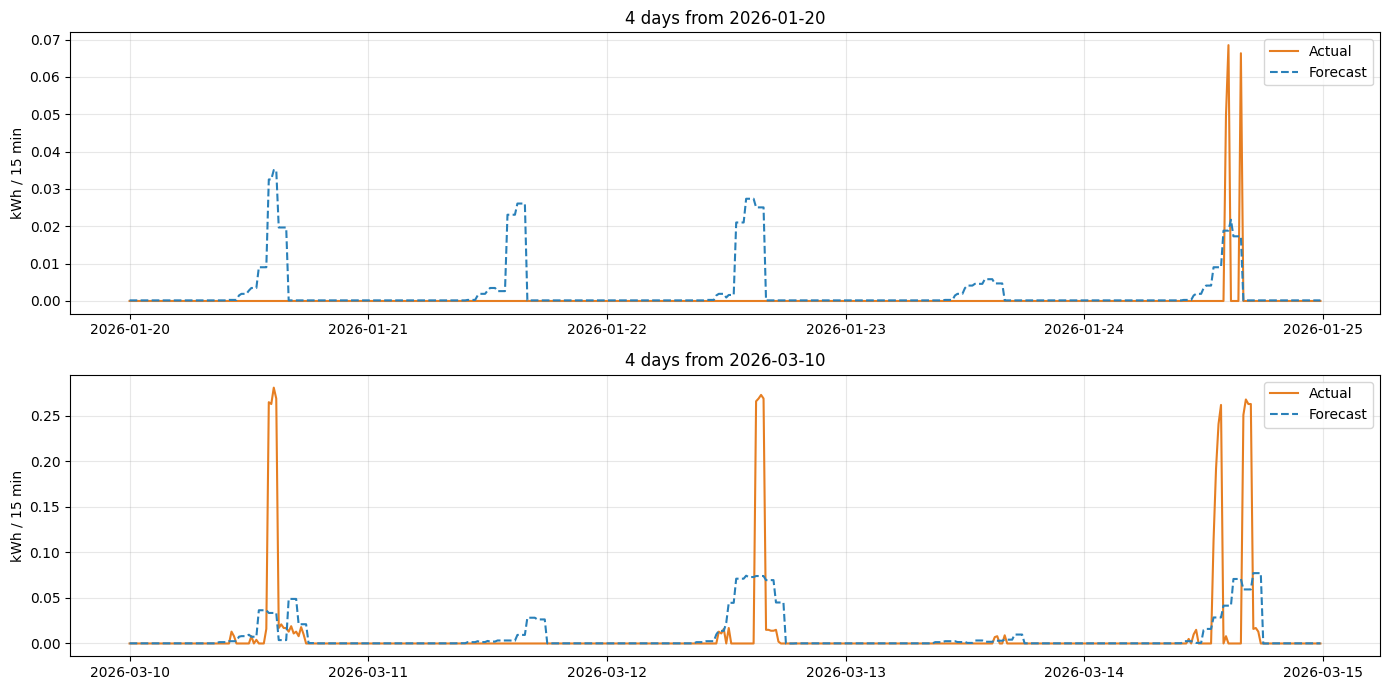

In [30]:
test = test.copy()
test["solar_pred"] = y_pred

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, start in zip(axes, ["2026-01-20", "2026-03-10"]):
    end = (pd.Timestamp(start) + pd.Timedelta(days=4)).strftime("%Y-%m-%d")
    w = test[start:end]
    ax.plot(w.index, w["sl_productie_kwh"], label="Actual",   color="#e67e22", lw=1.5)
    ax.plot(w.index, w["solar_pred"],       label="Forecast", color="#2980b9", lw=1.5, ls="--")
    ax.set_title(f"4 days from {start}")
    ax.set_ylabel("kWh / 15 min")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## §9. Feature importance

We expect `poa_irradiance` to dominate — it directly captures how much energy hits the panels.

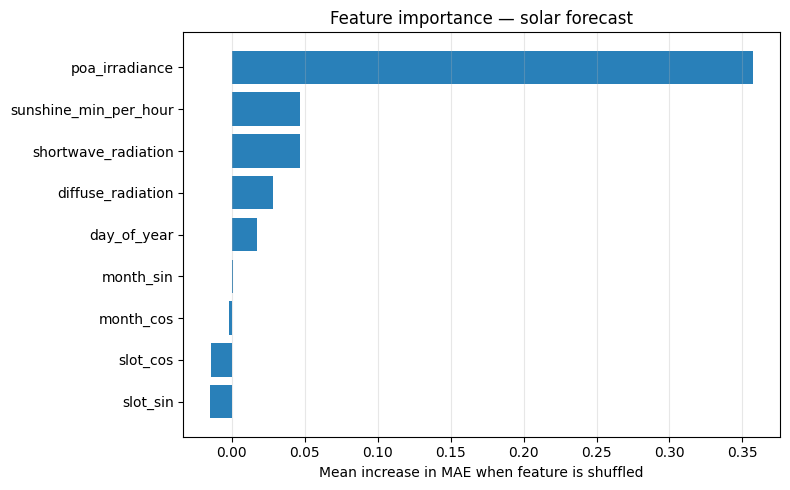

In [31]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": perm.importances_mean,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df["feature"], imp_df["importance"], color="#2980b9")
ax.set_xlabel("Mean increase in MAE when feature is shuffled")
ax.set_title("Feature importance — solar forecast")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## §10. Export

Predict for the full dataset and save to `solar_forecast.csv`.
This file will be used in `03_optimization_solar.ipynb` for the LP backtest.

In [32]:
all_preds = np.maximum(model.predict(merged[FEATURES]), 0)
merged["solar_pred"] = all_preds

output = merged[["sl_productie_kwh", "solar_pred"]].copy()
output.columns = ["sl_productie_actual", "sl_productie_forecast"]
output.to_csv(OUTPUT_FILE)

print(f"Saved: {len(output)} rows -> {OUTPUT_FILE}")
print()
print(output.describe().round(4))

Saved: 50112 rows -> ..\..\Data\real_load\Final\solar_forecast.csv

       sl_productie_actual  sl_productie_forecast
count           50112.0000             50112.0000
mean                0.0195                 0.0198
std                 0.0746                 0.0582
min                 0.0000                 0.0000
25%                 0.0000                 0.0001
50%                 0.0000                 0.0002
75%                 0.0000                 0.0020
max                 0.7630                 0.4818
